# Full upper-PPO training and validation analysis

This report analyzes the newest completed upper-agent run end to end. It checks run integrity, learning progression, scenario-specific performance, bias quality, action saturation, load/SLA behavior, handover safety, and validation generalization.

In [1]:
import json, os
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', '/tmp/mpl')
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
os.chdir(ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
RUN_DIR = sorted((ROOT/'models/upper_ppo_3gnb').glob('run_*'), key=lambda p:p.stat().st_mtime)[-1]
config = json.loads((RUN_DIR/'config.json').read_text())
train = pd.read_csv(RUN_DIR/'training_log.csv')
valid = pd.read_csv(RUN_DIR/'validation_log.csv')
SLICE_TYPES = tuple(config['slice_types'])
print('Run:', RUN_DIR)
print('Training:', train.shape, '| Validation:', valid.shape)


Run: /home/oussama/Desktop/chech/models/upper_ppo_3gnb/run_20260619_143855
Training: (20224, 139) | Validation: (204, 41)


## 1. Run integrity and timing

This section verifies that training reached its target, models were saved, episode clocks reached scenario durations, and the log contains no missing values.

In [2]:
train_terminal = train[train.done].copy()
train_episode = train_terminal.set_index('episode').copy()
valid_episode = valid.groupby('episode', as_index=False).agg(
    scenario_name=('scenario_name','first'),
    episode_return=('reward','sum'),
    start_variance=('load_imbalance_start','first'),
    final_variance=('load_imbalance_end','last'),
    final_sla=('sla_count','last'),
    handovers=('handover_count','sum'),
    duration_s=('episode_duration_s','max'),
    final_time_s=('episode_time_s','max'),
)
integrity = pd.Series({
    'configured timesteps': config['total_timesteps'],
    'logged timesteps': int(train.step.max()),
    'completed training episodes': len(train_terminal),
    'validation episodes': valid.episode.nunique(),
    'training missing cells': int(train.isna().sum().sum()),
    'final model exists': (RUN_DIR/'upper_ppo_final.zip').exists(),
    'best model exists': (RUN_DIR/'upper_ppo_best.zip').exists(),
    'all completed clocks exact': bool(np.allclose(train_terminal.episode_time_s, train_terminal.episode_duration_s)),
})
display(integrity.to_frame('value'))
display(pd.Series({
    'upper window seconds': config['upper_window_seconds'],
    'local mobility step seconds': train.local_step_seconds.iloc[0],
    'radio service seconds per upper window': train.radio_service_seconds_per_upper_window.iloc[0],
}).to_frame('value'))


,value
configured timesteps,20000
logged timesteps,20224
completed training episodes,1011
validation episodes,10
training missing cells,0
final model exists,True
best model exists,True
all completed clocks exact,True


,value
upper window seconds,1.0
local mobility step seconds,0.1
radio service seconds per upper window,0.1


## 2. Overall learning progression

Raw episode metrics are faint; the dark curve is a 60-episode rolling mean. Improvement should appear as a higher return and lower final load variance.

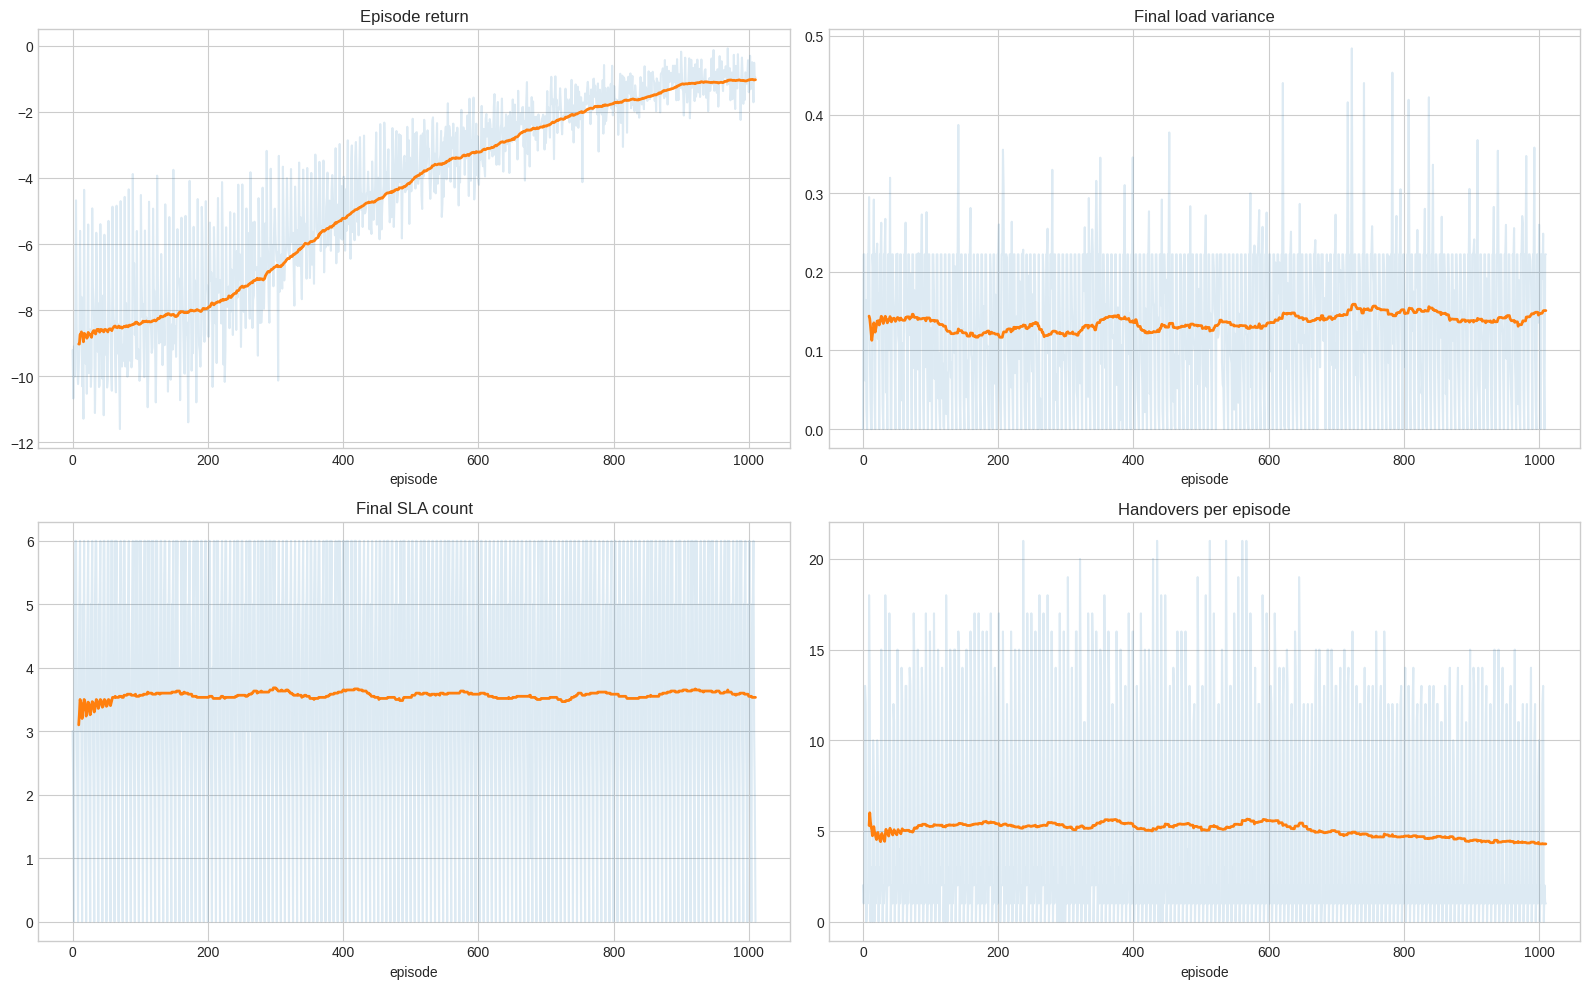

,first episodes,last episodes,change
episode_return,-8.5119,-1.0443,7.4676
load_variance,0.1396,0.1438,0.0042
sla_count,3.5000,3.5400,0.0400
total_handovers,5.1500,4.2100,-0.9400


In [3]:
episodes = train_terminal.sort_values('episode').copy()
episodes['total_handovers'] = train.groupby('episode').handover_count.sum().reindex(episodes.episode).to_numpy()
roll = 60
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = [
    ('episode_return','Episode return'),
    ('load_variance','Final load variance'),
    ('sla_count','Final SLA count'),
    ('total_handovers','Handovers per episode'),
]
for ax, (column,title) in zip(axes.flat, metrics):
    ax.plot(episodes.episode, episodes[column], alpha=.15)
    ax.plot(episodes.episode, episodes[column].rolling(roll,min_periods=10).mean(), linewidth=2)
    ax.set_title(title); ax.set_xlabel('episode')
plt.tight_layout(); plt.show()

n = min(100, len(episodes)//3)
progress = pd.DataFrame({
    'first episodes': episodes.head(n)[['episode_return','load_variance','sla_count','total_handovers']].mean(),
    'last episodes': episodes.tail(n)[['episode_return','load_variance','sla_count','total_handovers']].mean(),
})
progress['change'] = progress['last episodes'] - progress['first episodes']
display(progress.round(4))


## 3. Per-scenario learning

Scenario aggregation prevents an easy scenario from hiding poor behavior elsewhere. The table compares each scenario's first and last 30 completed episodes.

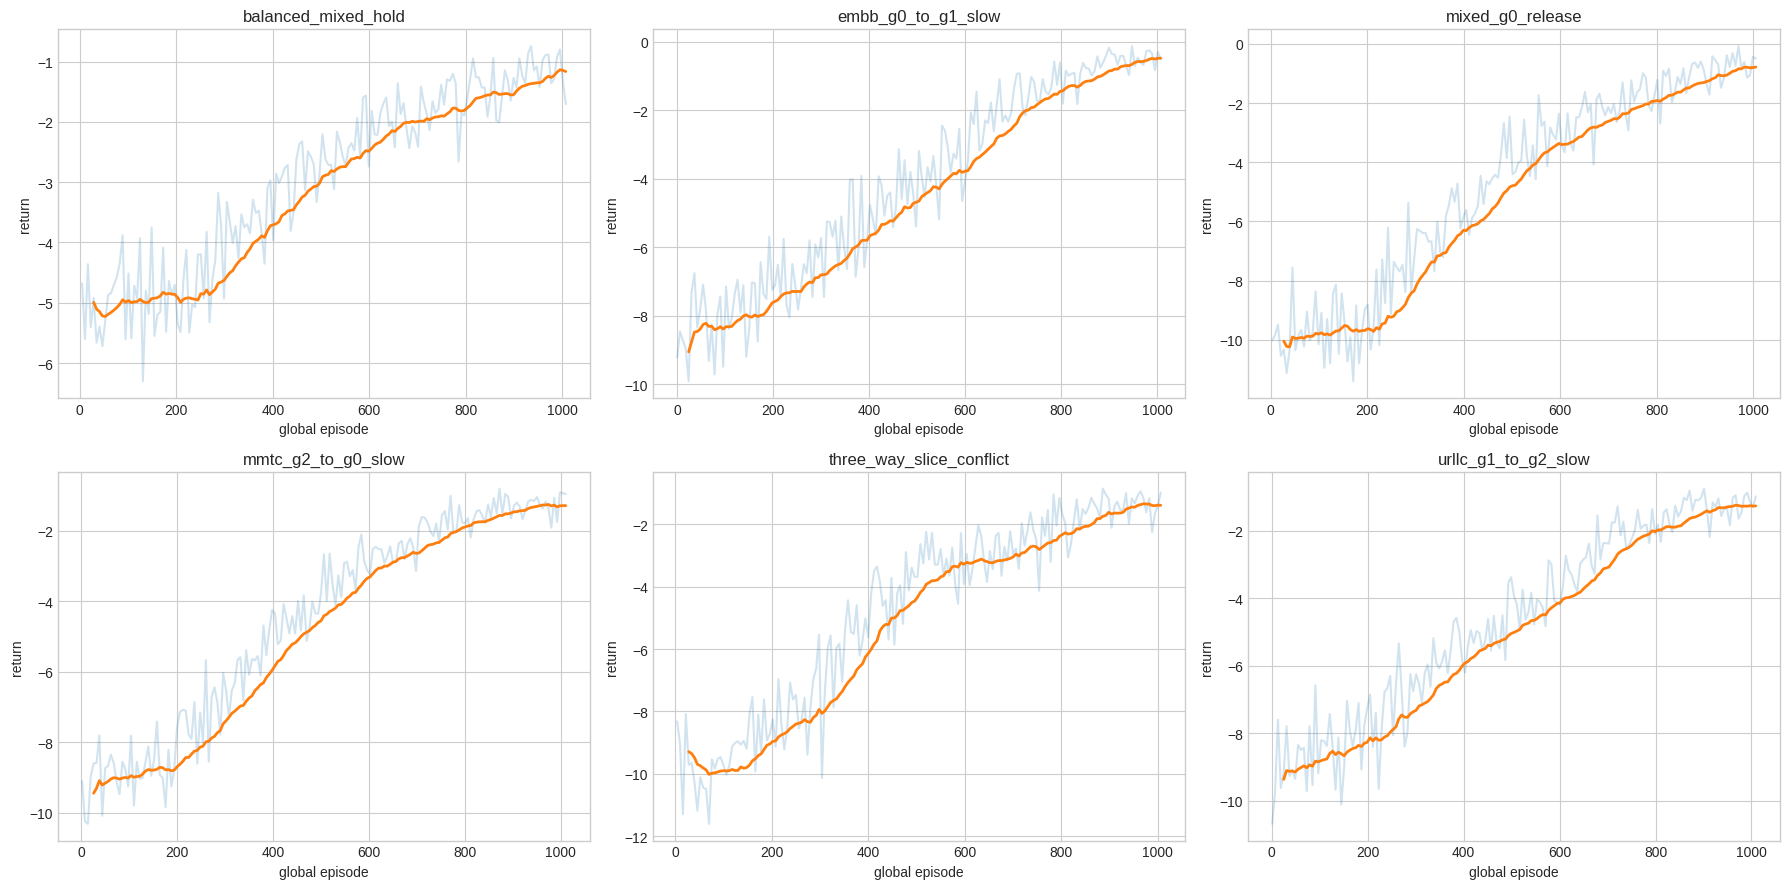

,episodes,return first,return last,variance first,variance last
scenario,,,,,
balanced_mixed_hold,168,-4.9682,-1.2862,0.0627,0.0595
embb_g0_to_g1_slow,169,-8.0781,-0.6032,0.0000,0.0000
mixed_g0_release,168,-9.7525,-0.9152,0.1496,0.2150
mmtc_g2_to_g0_slow,169,-8.8868,-1.2925,0.2222,0.2217
three_way_slice_conflict,168,-9.5127,-1.4100,0.1417,0.1433
urllc_g1_to_g2_slow,169,-8.6396,-1.2759,0.2074,0.2222


In [4]:
scenario_rows=[]
fig, axes = plt.subplots(2,3,figsize=(18,9))
for ax,(name,part) in zip(axes.flat, episodes.groupby('scenario_name',sort=True)):
    part=part.sort_values('episode')
    ax.plot(part.episode,part.episode_return,alpha=.2)
    ax.plot(part.episode,part.episode_return.rolling(20,min_periods=5).mean(),linewidth=2)
    ax.set_title(name); ax.set_xlabel('global episode'); ax.set_ylabel('return')
    k=min(30,len(part)//3)
    scenario_rows.append({
        'scenario':name,'episodes':len(part),
        'return first':part.head(k).episode_return.mean(),
        'return last':part.tail(k).episode_return.mean(),
        'variance first':part.head(k).load_variance.mean(),
        'variance last':part.tail(k).load_variance.mean(),
    })
plt.tight_layout(); plt.show()
scenario_progress=pd.DataFrame(scenario_rows).set_index('scenario')
display(scenario_progress.round(4))


## 3b. Load-variance improvement metric

Absolute final variance is difficult to compare across scenarios because each scenario starts with a different amount and placement of traffic. The balancing metric used here is:

`variance improvement = variance before the episode − variance after the episode`

Positive values mean the upper agent improved load balance. Zero means no spatial balancing change, and negative values mean the final distribution became less balanced.

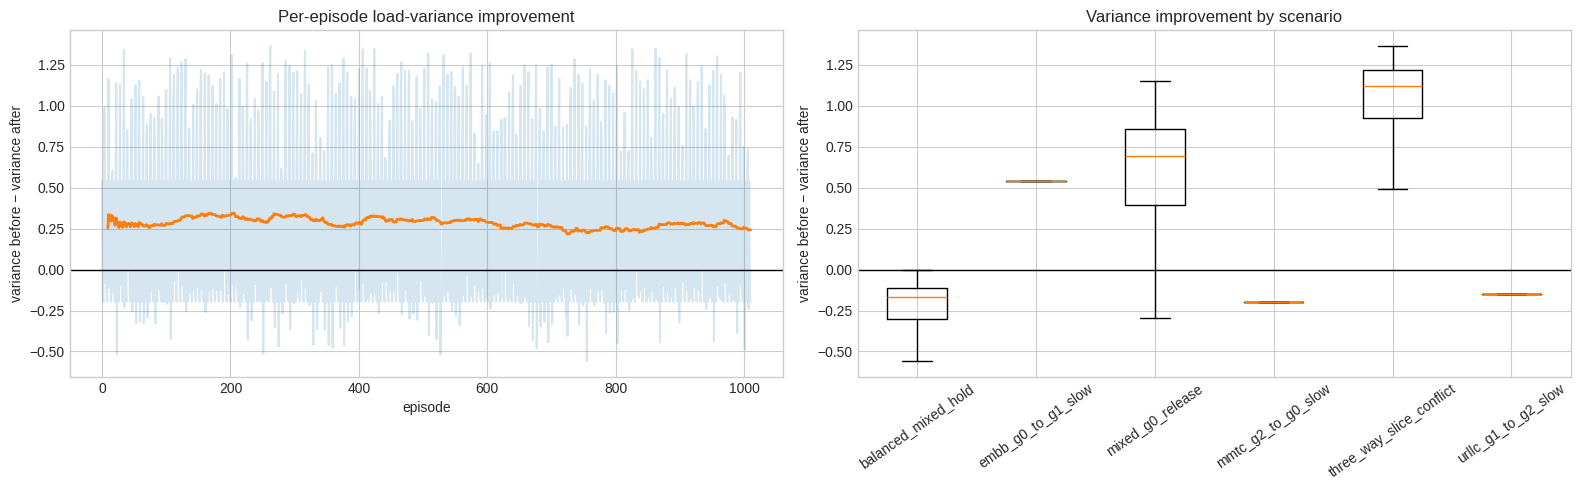

,episodes,mean,median,std,positive_fraction
scenario_name,,,,,
balanced_mixed_hold,168,-0.20823,-0.16453,0.13178,0.00000
embb_g0_to_g1_slow,169,0.53211,0.54000,0.07231,0.98817
mixed_g0_release,168,0.62667,0.69233,0.31475,0.95238
mmtc_g2_to_g0_slow,169,-0.19596,-0.19627,0.00278,0.00000
three_way_slice_conflict,168,1.06378,1.12267,0.20428,1.00000
urllc_g1_to_g2_slow,169,-0.11797,-0.15040,0.14225,0.04734


In [5]:
episode_bounds = train.groupby('episode', as_index=False).agg(
    scenario_name=('scenario_name','first'),
    completed=('done','max'),
    variance_before=('load_imbalance_start','first'),
    variance_after=('load_imbalance_end','last'),
)
episode_bounds = episode_bounds[episode_bounds.completed].copy()
episode_bounds['variance_improvement'] = (
    episode_bounds.variance_before - episode_bounds.variance_after
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(episode_bounds.episode, episode_bounds.variance_improvement, alpha=0.18)
axes[0].plot(
    episode_bounds.episode,
    episode_bounds.variance_improvement.rolling(60, min_periods=10).mean(),
    linewidth=2,
)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Per-episode load-variance improvement')
axes[0].set_xlabel('episode')
axes[0].set_ylabel('variance before − variance after')

scenario_order = sorted(episode_bounds.scenario_name.unique())
axes[1].boxplot(
    [episode_bounds.loc[episode_bounds.scenario_name == name, 'variance_improvement'] for name in scenario_order],
    tick_labels=scenario_order,
    showfliers=False,
)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Variance improvement by scenario')
axes[1].set_ylabel('variance before − variance after')
axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

variance_summary = episode_bounds.groupby('scenario_name').variance_improvement.agg(
    episodes='count', mean='mean', median='median', std='std',
    positive_fraction=lambda values: float(np.mean(values > 0)),
)
display(variance_summary.round(5))


### Per-slice variance improvement

The aggregate metric sums spatial variance over eMBB, URLLC, and mMTC. This cell separates the slices so improvement in one slice cannot hide degradation in another.

slice_type,URLLC,eMBB,mMTC
scenario_name,,,
balanced_mixed_hold,-0.01058,-0.00409,-0.00423
embb_g0_to_g1_slow,0.00000,0.20958,0.00000
mixed_g0_release,-0.03752,-0.02091,-0.02879
mmtc_g2_to_g0_slow,0.00000,0.00000,-0.02014
three_way_slice_conflict,0.16608,0.15121,0.15187
urllc_g1_to_g2_slow,-0.00575,0.00000,0.00000


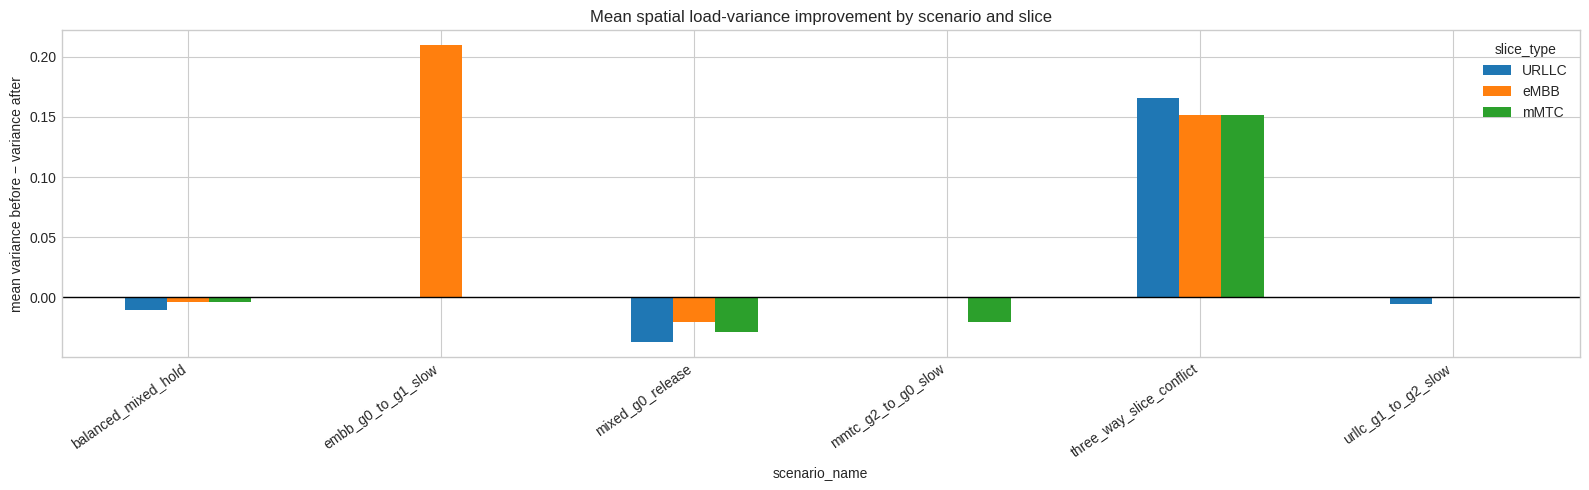

,count,mean,median
scenario_name,,,
balanced_mixed_hold,1,-0.08533,-0.08533
embb_g0_to_g1_slow,2,0.54000,0.54000
mixed_g0_release,2,0.41007,0.41007
mmtc_g2_to_g0_slow,2,-0.19627,-0.19627
three_way_slice_conflict,1,0.70800,0.70800
urllc_g1_to_g2_slow,2,-0.15040,-0.15040


In [6]:
slice_rows = []
for episode, part in train.groupby('episode'):
    if not bool(part.done.iloc[-1]):
        continue
    first_load = part.iloc[0][[f'load_g{g}_{s}' for g in range(3) for s in SLICE_TYPES]].to_numpy(dtype=float).reshape(3,3)
    last_load = part.iloc[-1][[f'load_g{g}_{s}' for g in range(3) for s in SLICE_TYPES]].to_numpy(dtype=float).reshape(3,3)
    for s_idx, slice_type in enumerate(SLICE_TYPES):
        before = float(np.var(first_load[:, s_idx]))
        after = float(np.var(last_load[:, s_idx]))
        slice_rows.append({
            'episode': episode,
            'scenario_name': part.scenario_name.iloc[0],
            'slice_type': slice_type,
            'variance_before': before,
            'variance_after': after,
            'variance_improvement': before - after,
        })
slice_variance = pd.DataFrame(slice_rows)
slice_summary = slice_variance.groupby(['scenario_name','slice_type']).variance_improvement.mean().unstack(fill_value=0)
display(slice_summary.round(5))
slice_summary.plot(kind='bar', figsize=(16,5))
plt.axhline(0, color='black', linewidth=1)
plt.ylabel('mean variance before − variance after')
plt.title('Mean spatial load-variance improvement by scenario and slice')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

valid_episode['variance_improvement'] = valid_episode.start_variance - valid_episode.final_variance
display(
    valid_episode.groupby('scenario_name').variance_improvement.agg(['count','mean','median']).round(5)
)


## 4. Upper action quality and saturation

The desired sign is negative for above-average source loads and positive for below-average loads. This section also measures how often PPO actions saturate near ±1.

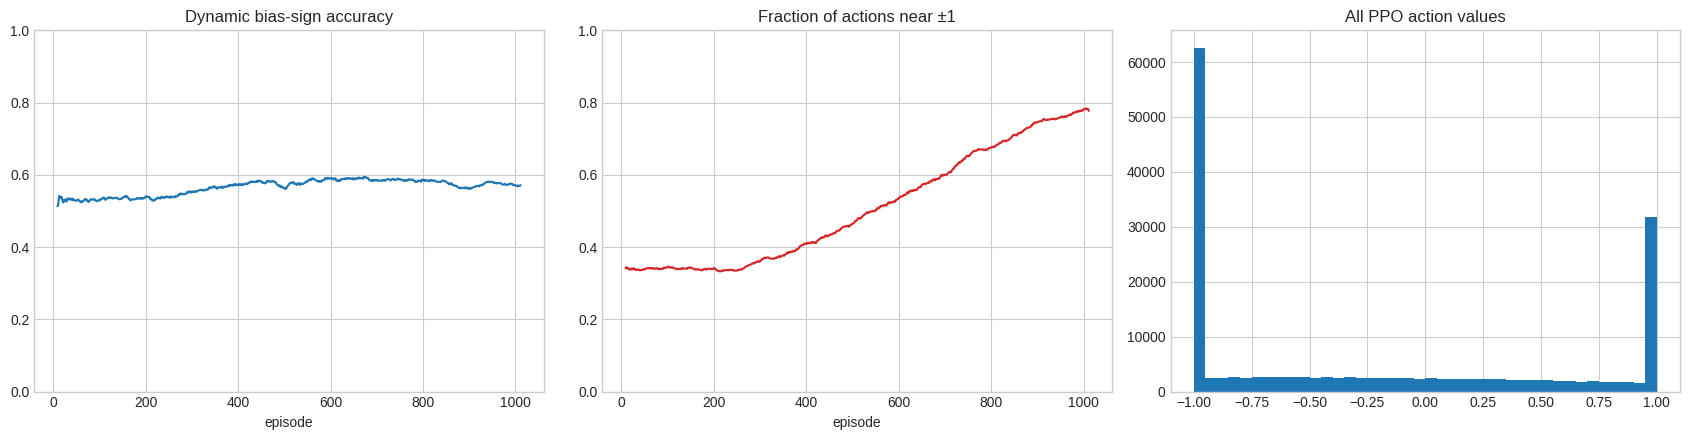

,value
mean dynamic sign accuracy,0.5609
last 20% sign accuracy,0.5632
mean action saturation,0.5189
last 20% action saturation,0.7558


In [7]:
action_cols=[f'action_{i}' for i in range(9)]
actions=train[action_cols].clip(-1,1)
loads=train[[f'load_g{g}_{s}' for g in range(3) for s in SLICE_TYPES]].to_numpy().reshape(-1,3,3)
bias=train[[f'bias_g{g}_{s}' for g in range(3) for s in SLICE_TYPES]].to_numpy().reshape(-1,3,3)
means=loads.mean(axis=1,keepdims=True)
above=loads>means+0.05; below=loads<means-0.05
active=above|below
correct=(above&(bias<0)) | (below&(bias>0))
active_count=active.sum(axis=(1,2))
sign_accuracy=np.divide(correct.sum(axis=(1,2)),active_count,out=np.ones(len(train)),where=active_count>0)
diagnostics=pd.DataFrame({
    'dynamic_sign_accuracy':sign_accuracy,
    'action_saturation':np.mean(np.abs(actions.to_numpy())>=0.95,axis=1),
},index=train.index)

fig,axes=plt.subplots(1,3,figsize=(17,4.5))
diagnostics.groupby(train.episode).dynamic_sign_accuracy.mean().rolling(60,min_periods=10).mean().plot(ax=axes[0])
axes[0].set_title('Dynamic bias-sign accuracy'); axes[0].set_ylim(0,1)
diagnostics.groupby(train.episode).action_saturation.mean().rolling(60,min_periods=10).mean().plot(ax=axes[1],color='tab:red')
axes[1].set_title('Fraction of actions near ±1'); axes[1].set_ylim(0,1)
actions.stack().hist(bins=40,ax=axes[2]); axes[2].set_title('All PPO action values')
plt.tight_layout(); plt.show()
display(pd.Series({
    'mean dynamic sign accuracy':diagnostics.dynamic_sign_accuracy.mean(),
    'last 20% sign accuracy':diagnostics.tail(len(train)//5).dynamic_sign_accuracy.mean(),
    'mean action saturation':diagnostics.action_saturation.mean(),
    'last 20% action saturation':diagnostics.tail(len(train)//5).action_saturation.mean(),
}).to_frame('value').round(4))


## 5. Reward decomposition

The dense reward equals load-balance improvement minus action smoothness cost. This plot checks whether penalties dominate the useful network improvement.

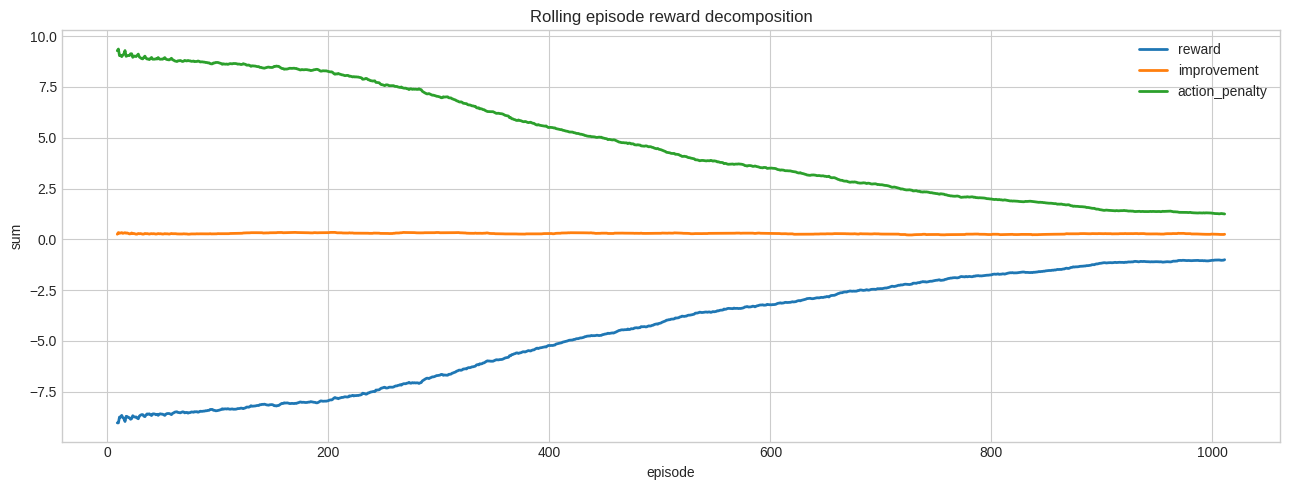

,reward,global_cost_improvement,global_action_penalty
count,20224.0000,20224.0000,20224.0000
mean,-0.2156,0.0142,0.2298
std,0.2682,0.1968,0.1840
min,-1.6425,-1.3963,0.0000
25%,-0.3758,-0.0205,0.0792
50%,-0.1977,0.0000,0.1910
75%,-0.0563,0.0133,0.3376
max,1.0504,1.1752,1.1770


In [8]:
reward_parts=train.groupby('episode').agg(
    reward=('reward','sum'), improvement=('global_cost_improvement','sum'),
    action_penalty=('global_action_penalty','sum'),
).rolling(60,min_periods=10).mean()
reward_parts.plot(figsize=(13,5),linewidth=2)
plt.title('Rolling episode reward decomposition'); plt.xlabel('episode'); plt.ylabel('sum')
plt.tight_layout(); plt.show()
display(train[['reward','global_cost_improvement','global_action_penalty']].describe().round(4))


## 6. Safe-admission and mobility behavior

Admission JSON is expanded here. A high rejection count is not automatically bad: capacity and target-safety rejections are the mechanism preventing total migration.

,eligible,accepted,rejected_no_pressure,rejected_no_source_excess,rejected_no_target_headroom,rejected_capacity,rejected_target_safety
scenario_name,,,,,,,
balanced_mixed_hold,0,0,0,0,0,0,0
embb_g0_to_g1_slow,20897,364,5435,11470,77,2024,1527
mixed_g0_release,113742,2318,29855,52657,14425,11689,2798
mmtc_g2_to_g0_slow,4554,202,0,0,0,1674,2678
three_way_slice_conflict,113569,2002,27902,36508,28445,16325,2387
urllc_g1_to_g2_slow,7333,198,5002,10,448,1091,584


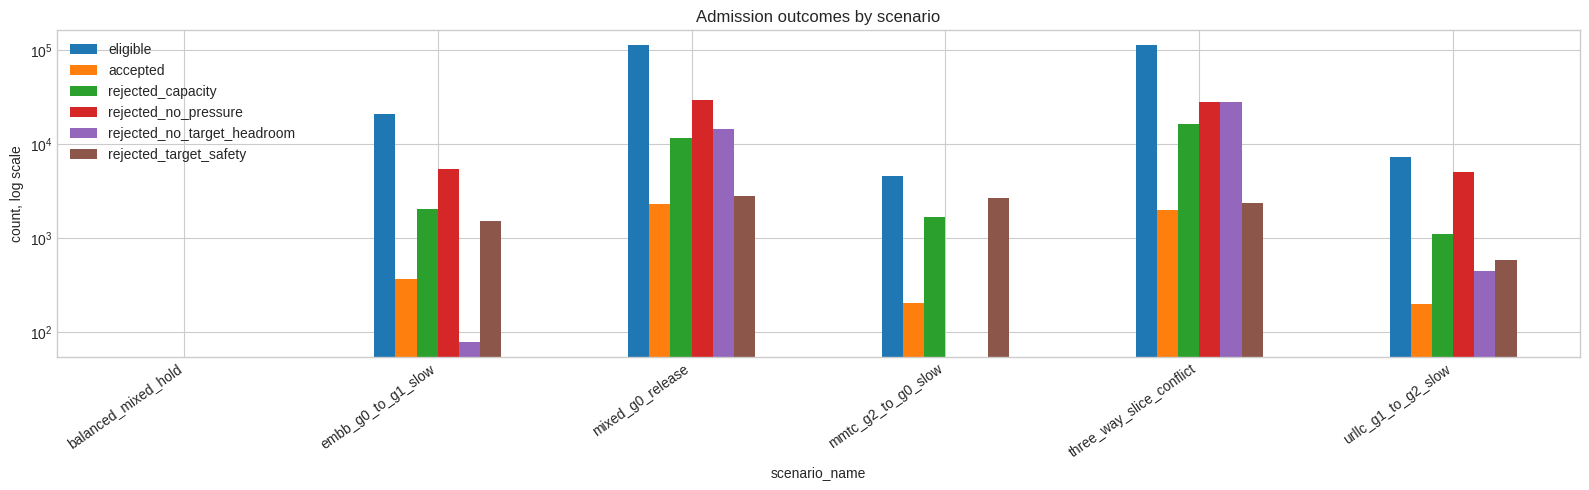

Overall candidate acceptance rate: 0.0195
Windows with target-safety rejection: 1134


In [9]:
admission=pd.DataFrame([json.loads(v) for v in train.safe_admission_stats])
admission['scenario_name']=train.scenario_name.values
by_scenario=admission.groupby('scenario_name').sum(numeric_only=True)
display(by_scenario)
by_scenario[['eligible','accepted','rejected_capacity','rejected_no_pressure','rejected_no_target_headroom','rejected_target_safety']].plot(
    kind='bar',figsize=(16,5),logy=True
)
plt.title('Admission outcomes by scenario'); plt.ylabel('count, log scale'); plt.xticks(rotation=35,ha='right')
plt.tight_layout(); plt.show()

acceptance=np.divide(admission.accepted,admission.eligible,out=np.zeros(len(admission)),where=admission.eligible>0)
print('Overall candidate acceptance rate:',round(admission.accepted.sum()/max(admission.eligible.sum(),1),4))
print('Windows with target-safety rejection:',int((admission.rejected_target_safety>0).sum()))


## 7. Training versus validation

Validation uses deterministic actions. The comparison uses the last available training episodes per scenario against validation episodes of the same scenario.

,train_return,train_final_variance,train_sla,valid_return,valid_final_variance,valid_sla,valid_handovers
scenario_name,,,,,,,
balanced_mixed_hold,-1.2862,0.0595,6.0000,-0.4165,0.0853,6.0,0.0
embb_g0_to_g1_slow,-0.6032,0.0000,3.0000,0.2742,0.0000,3.0,2.0
mixed_g0_release,-0.9152,0.2150,5.2333,0.1243,0.7449,6.0,10.5
mmtc_g2_to_g0_slow,-1.2925,0.2217,0.0000,-0.5591,0.6667,0.0,1.0
three_way_slice_conflict,-1.4100,0.1433,5.3333,0.4000,0.7733,4.0,11.0
urllc_g1_to_g2_slow,-1.2759,0.2222,2.0000,-0.4566,0.6667,2.0,1.0


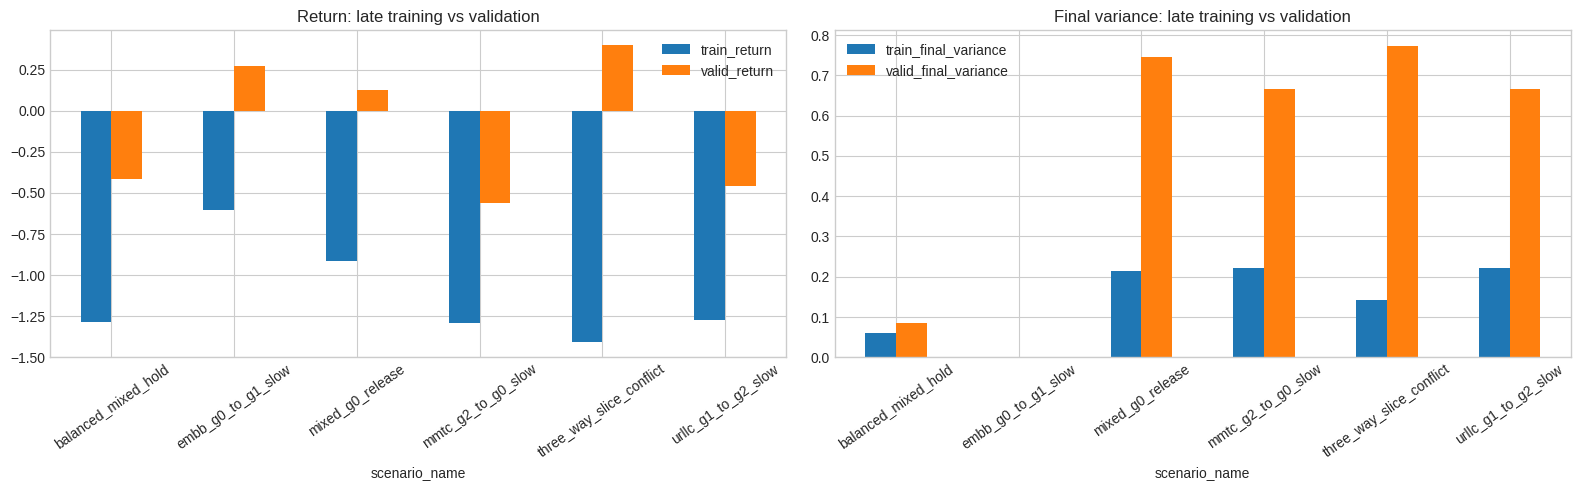

In [10]:
late_training=[]
for name,part in episodes.groupby('scenario_name'):
    tail=part.sort_values('episode').tail(30)
    late_training.append({
        'scenario_name':name,'train_return':tail.episode_return.mean(),
        'train_final_variance':tail.load_variance.mean(),
        'train_sla':tail.sla_count.mean(),
    })
late_training=pd.DataFrame(late_training).set_index('scenario_name')
valid_summary=valid_episode.groupby('scenario_name').agg(
    valid_return=('episode_return','mean'),valid_final_variance=('final_variance','mean'),
    valid_sla=('final_sla','mean'),valid_handovers=('handovers','mean'),
)
comparison=late_training.join(valid_summary)
display(comparison.round(4))

fig,axes=plt.subplots(1,2,figsize=(16,5))
comparison[['train_return','valid_return']].plot(kind='bar',ax=axes[0])
axes[0].set_title('Return: late training vs validation'); axes[0].tick_params(axis='x',rotation=35)
comparison[['train_final_variance','valid_final_variance']].plot(kind='bar',ax=axes[1])
axes[1].set_title('Final variance: late training vs validation'); axes[1].tick_params(axis='x',rotation=35)
plt.tight_layout(); plt.show()


## 8. Validation episode timelines

Each panel shows one deterministic validation episode. Vertical marks indicate handovers.

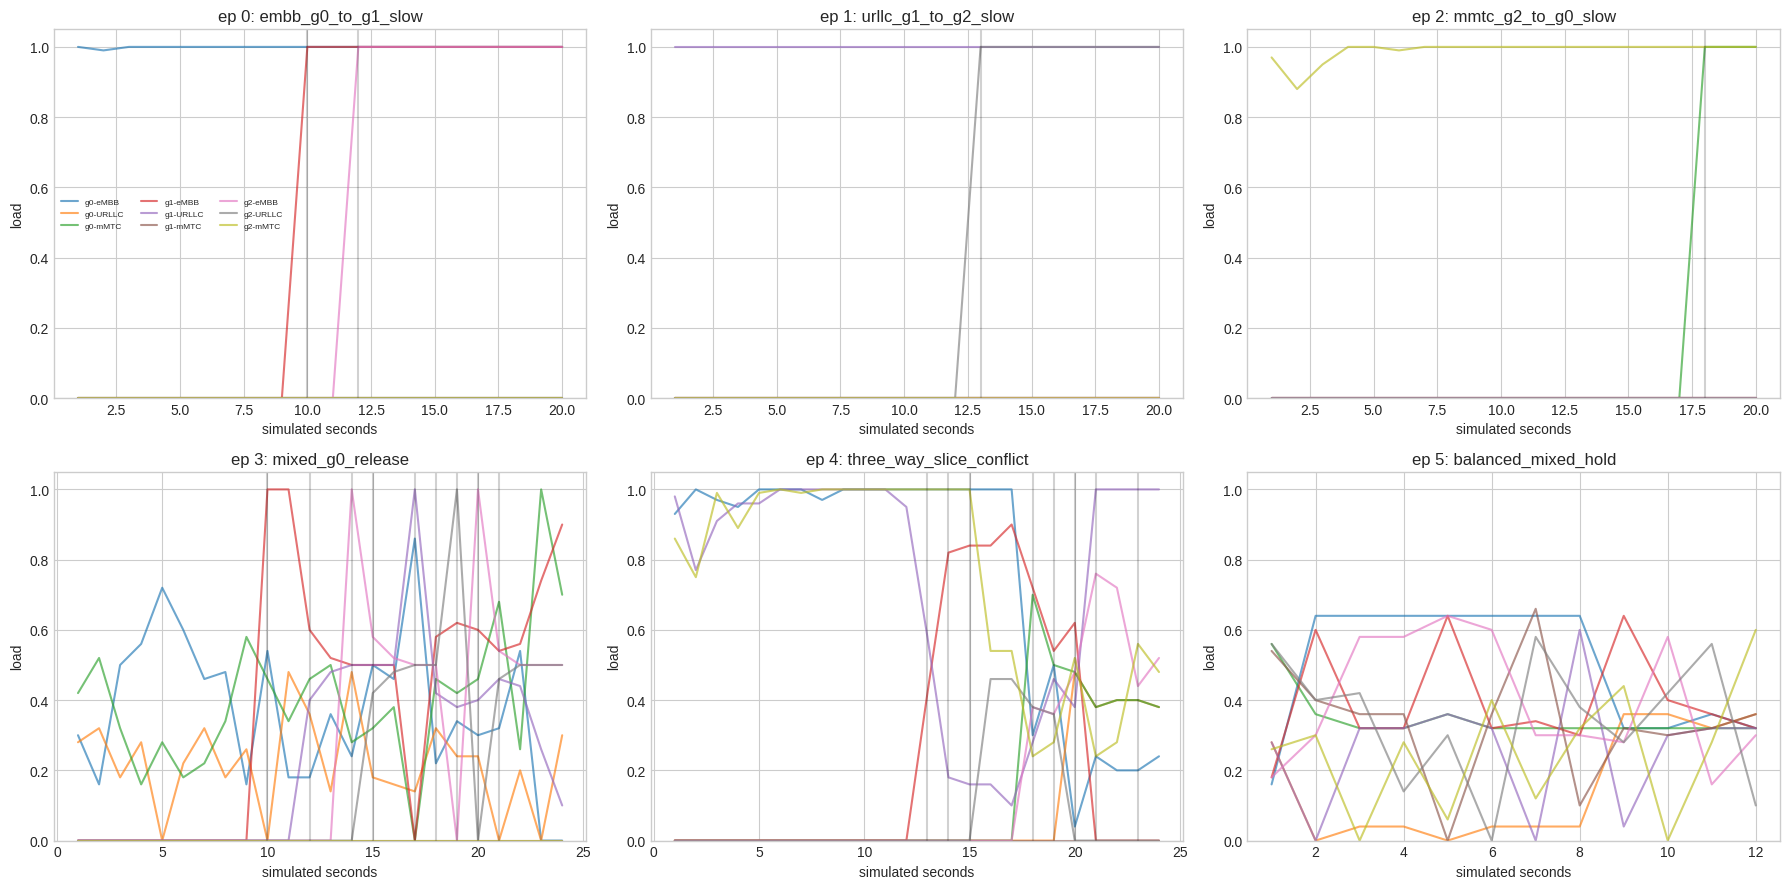

In [11]:
fig,axes=plt.subplots(2,3,figsize=(18,9))
for ax,(episode,part) in zip(axes.flat,valid.groupby('episode')):
    for g in range(3):
        for s_idx,s in enumerate(SLICE_TYPES):
            matrices=np.stack(part.load_matrix.map(lambda v:np.asarray(json.loads(v),dtype=float)))
            ax.plot(part.episode_time_s,matrices[:,g,s_idx],alpha=.65,label=f'g{g}-{s}')
    for t in part.loc[part.handover_count>0,'episode_time_s']:
        ax.axvline(t,color='black',alpha=.18)
    ax.set_title(f"ep {episode}: {part.scenario_name.iloc[0]}")
    ax.set_xlabel('simulated seconds'); ax.set_ylabel('load'); ax.set_ylim(0,1.05)
axes[0,0].legend(fontsize=6,ncol=3)
plt.tight_layout(); plt.show()


## 9. Final automated assessment

These checks summarize whether the run is complete and whether learning improved. They intentionally do not claim that every scenario is solved.

In [12]:
first_return=episodes.head(n).episode_return.mean(); last_return=episodes.tail(n).episode_return.mean()
first_var=episodes.head(n).load_variance.mean(); last_var=episodes.tail(n).load_variance.mean()
assessment=pd.Series({
    'run complete':train.step.max()>=config['total_timesteps'],
    'return improved':last_return>first_return,
    'final variance improved':last_var<first_var,
    'all scenarios trained':set(episodes.scenario_name)==set(valid.scenario_name),
    'validation clocks complete':bool(np.allclose(valid_episode.final_time_s,valid_episode.duration_s)),
    'validation mean return':valid_episode.episode_return.mean(),
    'validation mean variance reduction':(valid_episode.start_variance-valid_episode.final_variance).mean(),
})
display(assessment.to_frame('result'))
assert assessment['run complete']
assert assessment['return improved']
assert assessment['all scenarios trained']
assert assessment['validation clocks complete']
print('PASS: run integrity, learning progression, scenario coverage, and validation timing checks succeeded.')


,result
run complete,True
return improved,True
final variance improved,False
all scenarios trained,True
validation clocks complete,True
validation mean return,-0.125104
validation mean variance reduction,0.182947


PASS: run integrity, learning progression, scenario coverage, and validation timing checks succeeded.
